In [1]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

from pathlib import Path
analy_script_path = Path.cwd().parent.parent.parent / 'analysis'
if str(analy_script_path) not in sys.path:
    sys.path.append(str(analy_script_path))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
import corner
import seaborn as sb

from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc
import post_anal as pa



from aquarel import load_theme
theme_notused = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme = (
        load_theme("scientific")
        .set_font(family="serif", serif=["cmr10"]) # useless since text.usetex is set to True
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="xx-large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
            "axes.formatter.use_mathtext": "True",
            'mathtext.fontset':'cm',
            "text.usetex":"True"
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20
solo_fontsize = 16
cols = ['#ffac00', '#4e3fee', '#ea1900', '#8EC7D2', "#DC267F"]

plot_dir = "/home/sam/thesis/writingII/images/"

In [7]:
n = anal.get_n_test(n_end=10, numpoints=200)

injection_param = {'mass_1': 1.4013655921528583, 'mass_2': 1.251350789219395, 
                   'EOS': 15326, 'luminosity_distance': 186.1146, 
                   'ra': 1.520635390191212, 'dec': 0.45030007475911127, 
                   'theta_jn': 0.19155501532759683, 'psi': 1.8532224222721934, 
                   'phase': 3.869180533501537, 'geocent_time': 1807820461.0, 
                   'a_1': 0.02579833610105956, 'a_2': 0.01157992076217064, 
                   'tilt_1': 1.7821450323807169, 'tilt_2': 1.0741761809182178, 
                   'phi_12': 4.624654103350016, 'phi_jl': 1.2271620128137724, 
                   'chirp_mass': 1.1524448440960904, 'total_mass': 2.652716381372253, 
                   'symmetric_mass_ratio': 0.24920048502652759, 'mass_ratio': 0.8929509873986544, 
                   'redshift': 0.04074999863382214, 'mass_1_source': (1.34649589), 'mass_2_source': (1.20235483), 
                   'TOV_mass': 1.9963680478289905, 'TOV_radius': 10.412495133463992, 'lambda_1': 433.4925391647716, 
                   'lambda_2': 823.1592336148897, 'radius_1': 11.869081447022314, 'radius_2': 11.842364381411363, 
                   'R_14': 11.876464566522206, 'R_16': 11.889110278491556}

injection_param["lambda_tilde"] = (pa.lambda_tilde(injection_param["mass_1_source"], 
                                injection_param["mass_2_source"], injection_param["lambda_1"], 
                                injection_param["lambda_2"]) )


eos_rq, mr_rq = pa.load_eos_data('RQ_10ns_1')
injected_eos = eos_rq[:, injection_param["EOS"], :]
injected_mr = mr_rq[:, injection_param["EOS"], :]

injected_p3ns = pa.p_3ns(np.reshape(injected_eos, (3,1,275)))[0]
injection_param["p_3ns"] = injected_p3ns

eos_rq3, mr_rq3 = pa.load_eos_data('RQ_10ns_3')
inj_lam14 = np.interp(1.4,  mr_rq3[1, injection_param["EOS"], :], mr_rq3[2, injection_param["EOS"], :])
injection_param["lambda_14"] = inj_lam14

In [3]:
df_se = pa.load_inj_results(kernel_name = 'SE', set = 11)
df_se2 = pa.load_inj_results(kernel_name = 'SE', set = 2)
df_se3 = pa.load_inj_results(kernel_name = 'SE', set = 3)
df_se4 = pa.load_inj_results(kernel_name = 'SE', set = 4)
df_rq = pa.load_inj_results(kernel_name = 'RQ', set = 1)
df_ge = pa.load_inj_results(kernel_name = 'GE', set = 1)
df_m32 = pa.load_inj_results(kernel_name = 'M32', set = 1)
df_m52 = pa.load_inj_results(kernel_name = 'M52', set = 1)

eos_se, mr_se = pa.load_eos_data('SE_10ns_11')
eos_se2, mr_se2 = pa.load_eos_data('SE_10ns_2')
eos_se3, mr_se3 = pa.load_eos_data('SE_10ns_3')
eos_se4, mr_se4 = pa.load_eos_data('SE_10ns_4')
eos_rq, mr_rq = pa.load_eos_data('RQ_10ns_1')
eos_ge, mr_ge = pa.load_eos_data('GE_10ns_1')
eos_m32, mr_m32 = pa.load_eos_data('M32_10ns_1')
eos_m52, mr_m52 = pa.load_eos_data('M52_10ns_1')

eos_se_post, mr_se_post = pa.get_posterior_eos(df_se, eos_se, mr_se)
eos_se2_post, mr_se2_post = pa.get_posterior_eos(df_se2, eos_se2, mr_se2)
eos_se3_post, mr_se3_post = pa.get_posterior_eos(df_se3, eos_se3, mr_se3)
eos_se4_post, mr_se4_post = pa.get_posterior_eos(df_se4, eos_se4, mr_se4)
eos_rq_post, mr_rq_post = pa.get_posterior_eos(df_rq, eos_rq, mr_rq)
eos_ge_post, mr_ge_post = pa.get_posterior_eos(df_ge, eos_ge, mr_ge)
eos_m32_post, mr_m32_post = pa.get_posterior_eos(df_m32, eos_m32, mr_m32)
eos_m52_post, mr_m52_post = pa.get_posterior_eos(df_m52, eos_m52, mr_m52)

In [4]:
weight_se = pa.get_posterior_weights(df_se)
weight_se2 = pa.get_posterior_weights(df_se2)
weight_se3 = pa.get_posterior_weights(df_se3)
weight_se4 = pa.get_posterior_weights(df_se4)
weight_rq = pa.get_posterior_weights(df_rq)
weight_ge = pa.get_posterior_weights(df_ge)
weight_m32 = pa.get_posterior_weights(df_m32)
weight_m52 = pa.get_posterior_weights(df_m52)
weight_prior = pa.get_prior_weights(eos_se)


# SE

In [4]:
se_val_inds = pa.get_valid_eos(df_se)
se_inval_inds = [i for i in range(20000) if i not in se_val_inds]

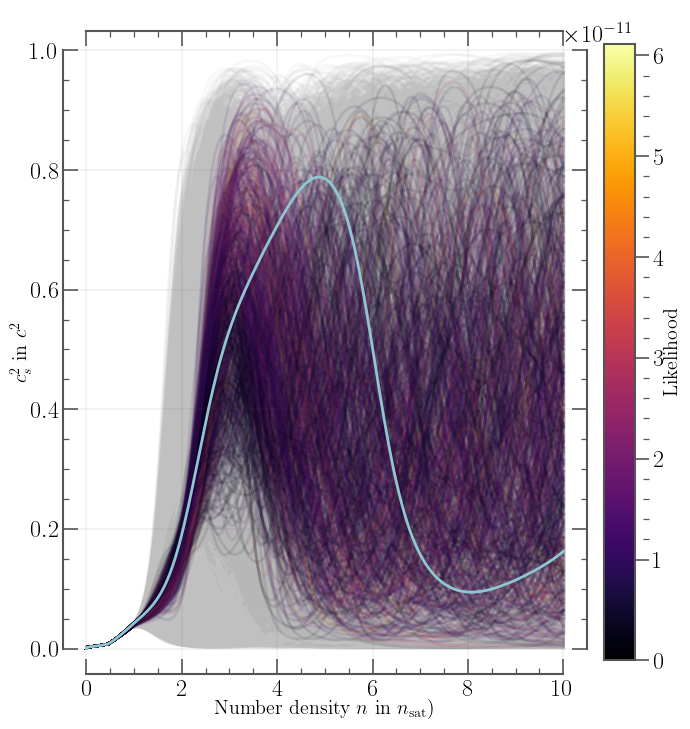

In [5]:
weights = np.array( 
        df_se.groupby('EOS')['Likelihood']
      .first()  
      )
norm = Normalize(vmin=weights.min(), vmax=weights.max())
cmap = plt.cm.inferno

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

for i,j in enumerate(se_val_inds):
    color = cmap(norm(weights[i]))
    if weights[i] > 0.10e-11:
        ax1.plot(n, eos_se[2, j, :], color=color, alpha=0.1, zorder=1)
    else:
        ax1.plot(n, eos_se[2, j, :], color=color, alpha=0.1, zorder=0)
for i in se_inval_inds:
    ax1.plot(n, eos_se[2, i, :], color='silver', alpha=0.1, zorder=0)

ax1.plot(n, injected_eos[2], color='#8EC7D2', alpha=1, zorder=2, label='Injected EOS')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label('Likelihood')

ax1.set_xlabel('Number density $n$ in $n_{\mathrm{sat}}$)')
ax1.set_ylabel('$c_s^2$ in $c^2$')
ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_cs2_posterior.png", dpi=300)
plt.show()

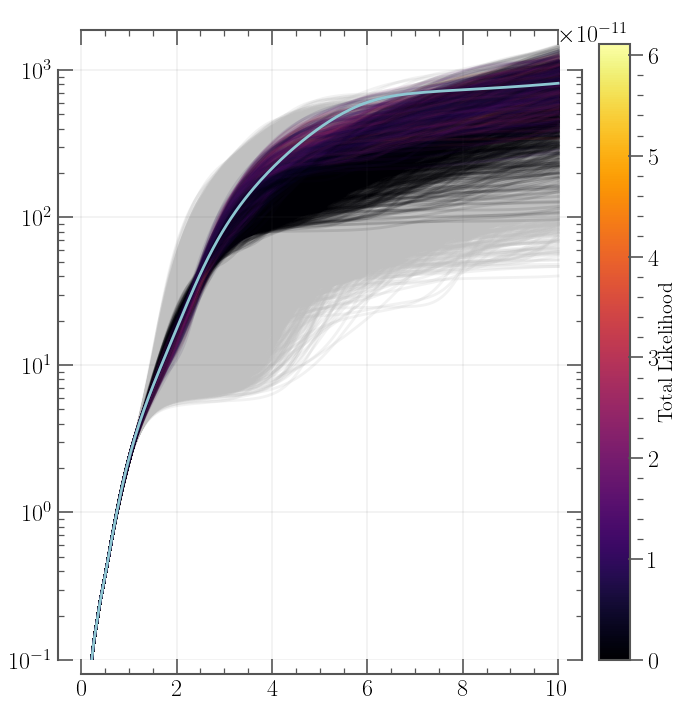

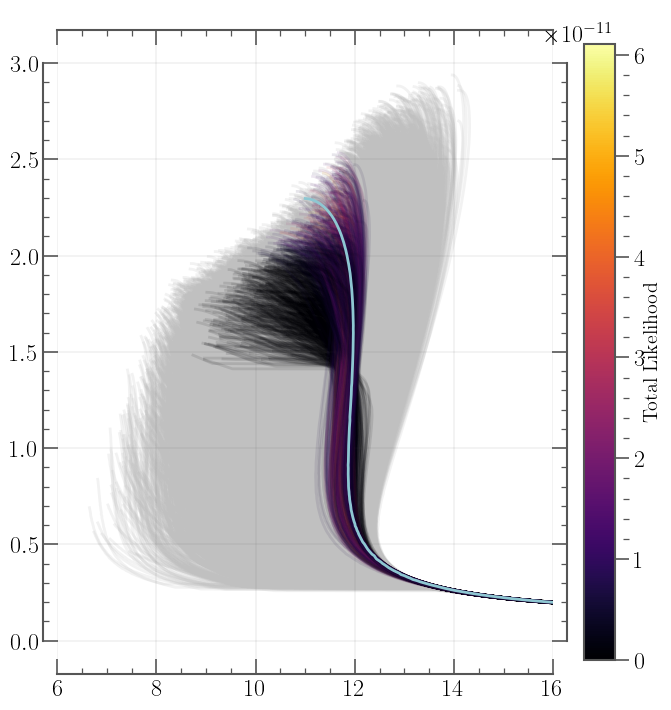

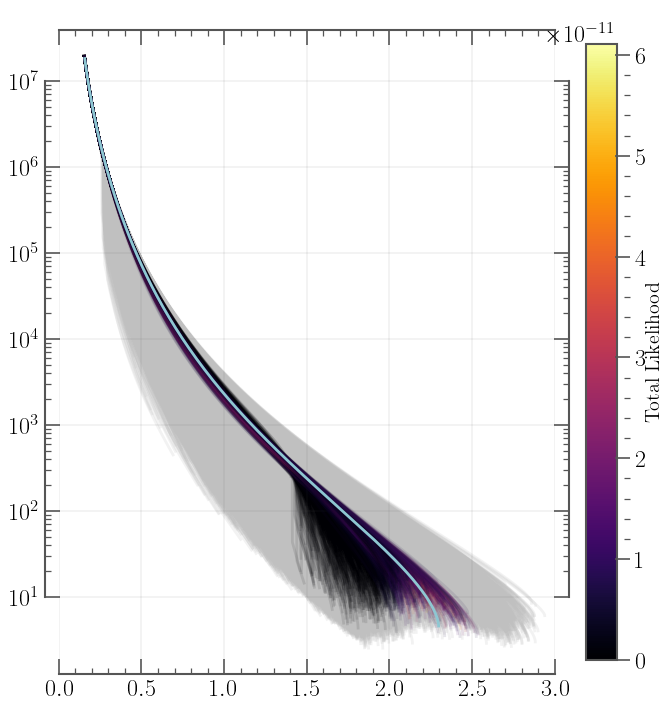

In [6]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

for i,j in enumerate(se_val_inds):
    color = cmap(norm(weights[i]))
    if weights[i] > 0.10e-11:
        ax1.plot(n, eos_se[1, j, :], color=color, alpha=0.1, zorder=2)
    else:
        ax1.plot(n, eos_se[1, j, :], color=color, alpha=0.1, zorder=1)

for i in se_inval_inds:
    ax1.plot(n, eos_se[1, i, :], color='silver', alpha=0.2, zorder=0)

ax1.plot(n, injected_eos[1], color='#8EC7D2', alpha=1, zorder=2, label='Injected EOS')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label('Total Likelihood')


plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_p_likelihood_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

for i,j in enumerate(se_val_inds):
    color = cmap(norm(weights[i]))
    if weights[i] > 0.10e-11:
        ax1.plot(mr_se[0, j, :], mr_se[1, j, :], color=color, alpha=0.1, zorder=2)
    else:
        ax1.plot(mr_se[0, j, :], mr_se[1, j, :], color=color, alpha=0.1, zorder=1)

for i in se_inval_inds:
    ax1.plot(mr_se[0, i, :], mr_se[1, i, :], color='silver', alpha=0.2, zorder=0)

ax1.plot(injected_mr[0], injected_mr[1], color='#8EC7D2', alpha=1, zorder=2, label='Injected EOS'
)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label('Total Likelihood')

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_mr_likelihood_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
for i,j in enumerate(se_val_inds):
    color = cmap(norm(weights[i]))
    if weights[i] > 0.10e-11:
        ax1.plot(mr_se[1, j, :], mr_se[2, j, :], color=color, alpha=0.1, zorder=2)
    else:
        ax1.plot(mr_se[1, j, :], mr_se[2, j, :], color=color, alpha=0.1, zorder=1)
for i in se_inval_inds:
    ax1.plot(mr_se[1, i, :], mr_se[2, i, :], color='silver', alpha=0.2, zorder=0)
ax1.plot(injected_mr[1], injected_mr[2], color='#8EC7D2', alpha=1, zorder=2, label='Injected EOS')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label('Total Likelihood')


ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_mt_likelihood_posterior.png", dpi=300)
plt.show()

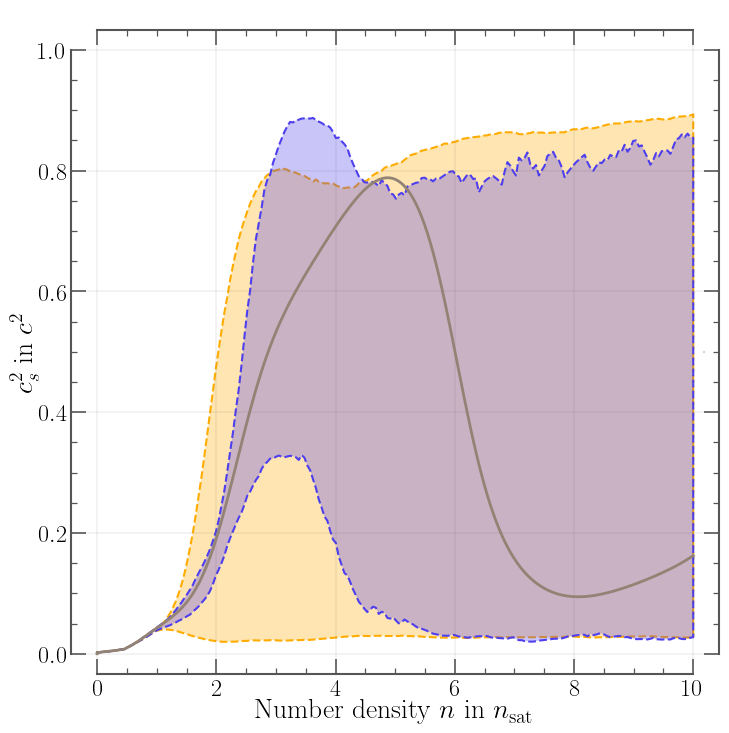

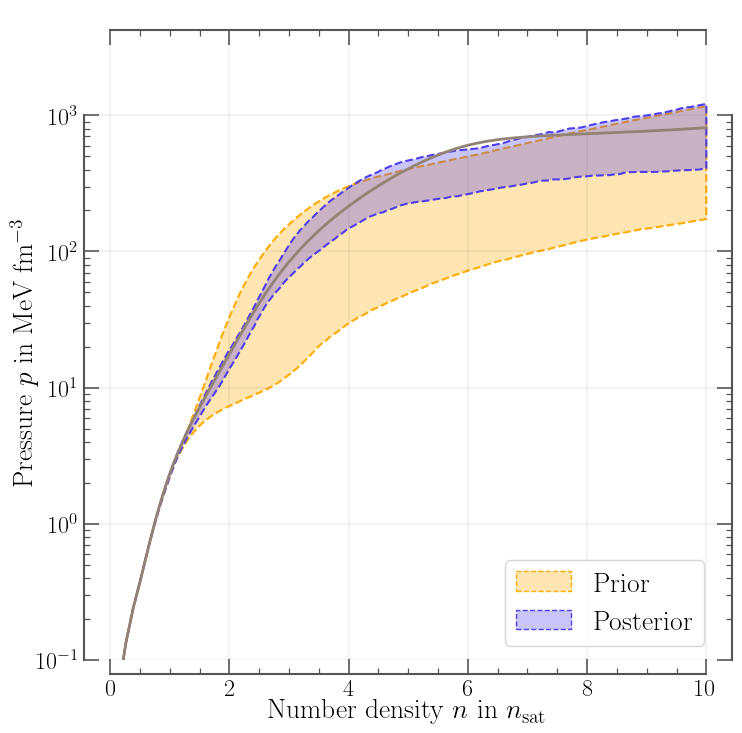

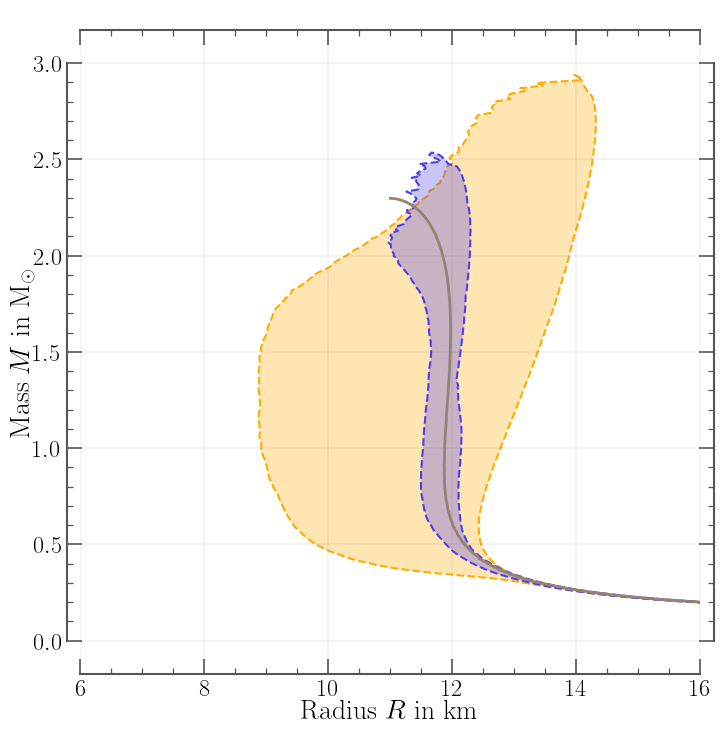

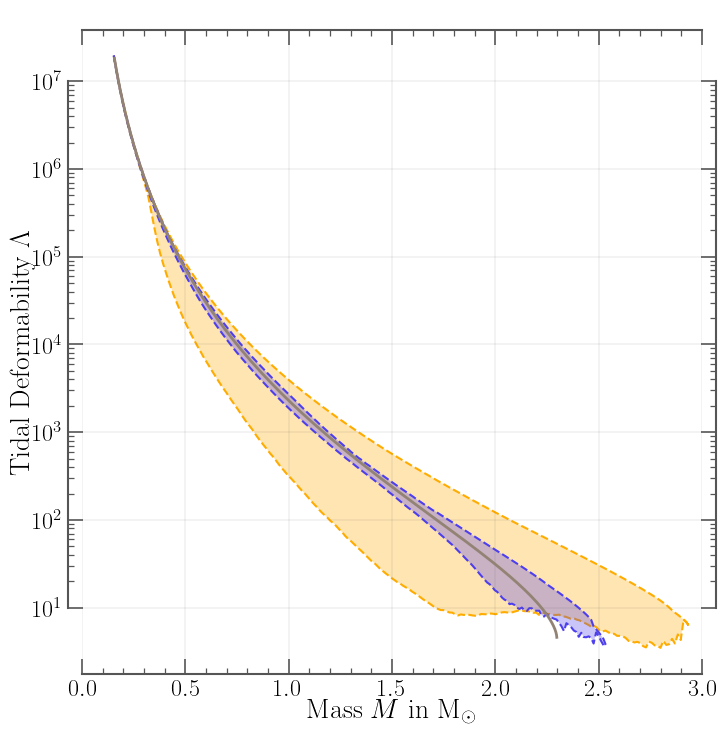

In [9]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se, eos_se_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se, mr_se_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_prior, weight_se])
ax1.plot(n, injected_eos[2], color='#928374', alpha=1, zorder=2, label='Injected EOS')
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se, eos_se_post], ax1=ax1, 
                        mr_list=[mr_se, mr_se_post], 
                        labels=["Prior", "Posterior"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_prior, weight_se])

ax1.plot(n, injected_eos[1], color='#928374', alpha=1, zorder=2, label='Injected EOS')

plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

pa.plot_eos_comparisons([eos_se, eos_se_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se, mr_se_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_prior, weight_se])
ax1.plot(injected_mr[0], injected_mr[1], color='#928374', alpha=1, zorder=2, label='Injected EOS')
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se, eos_se_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se, mr_se_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_prior, weight_se])
ax1.plot(injected_mr[1], injected_mr[2], color='#928374', alpha=1, zorder=2, label='Injected EOS')
ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_se_mt_posterior.png", dpi=300)
plt.show()

# Kernel Choice


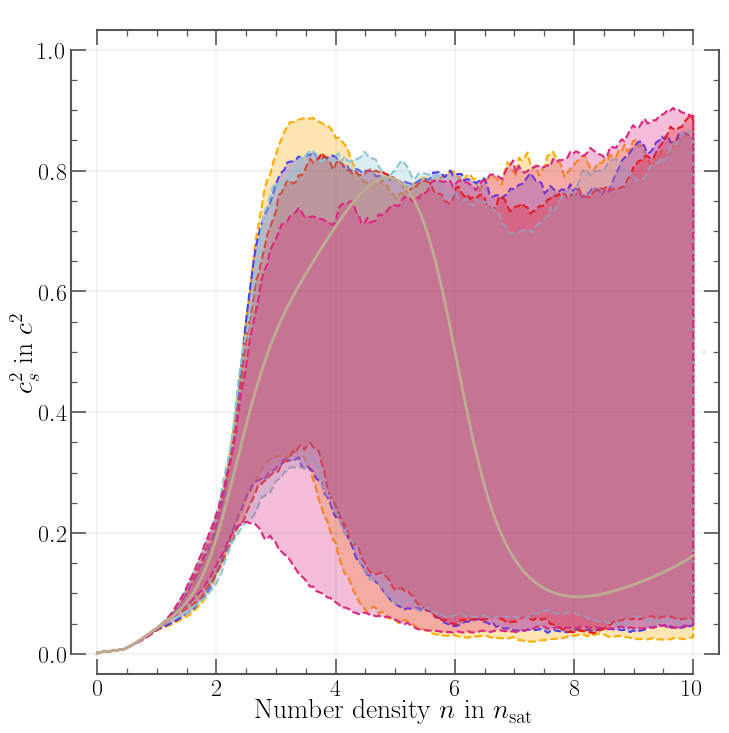

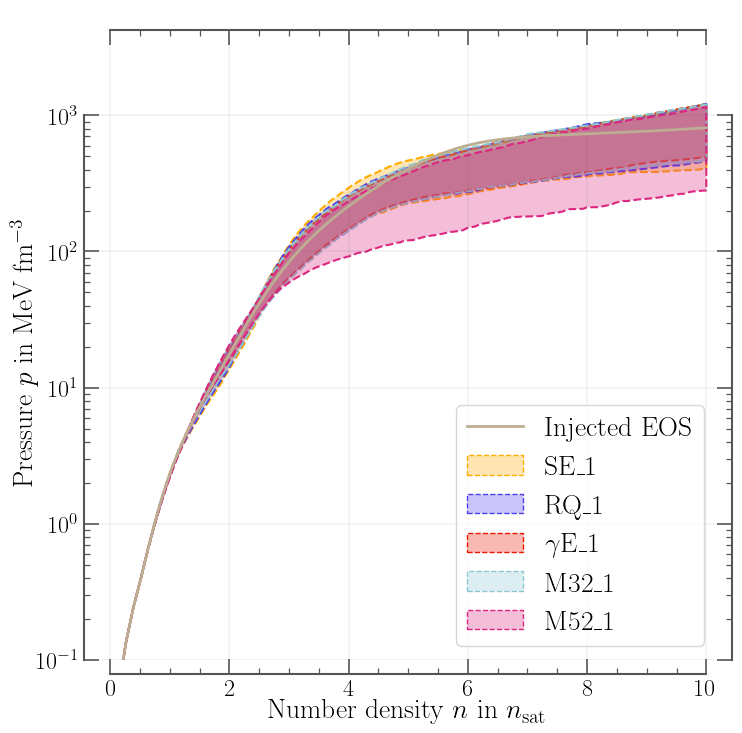

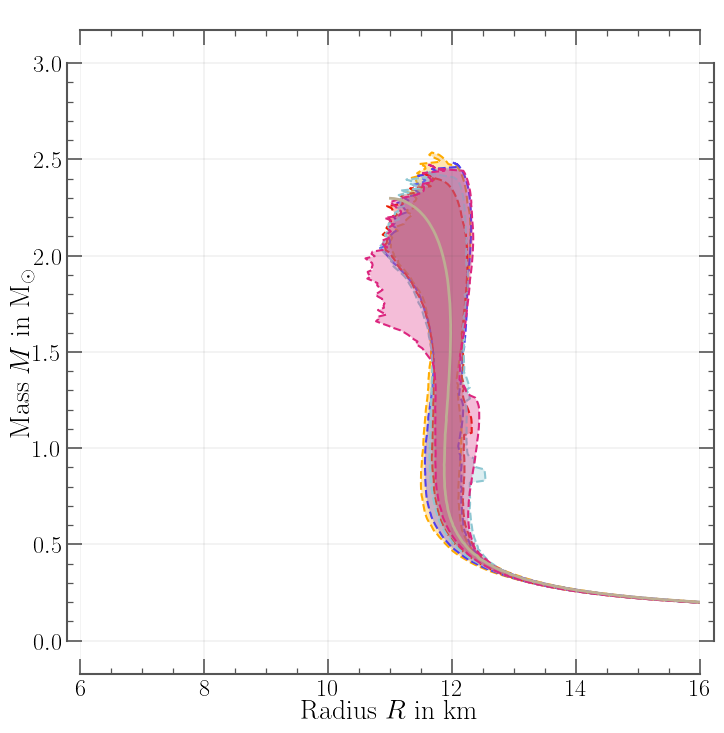

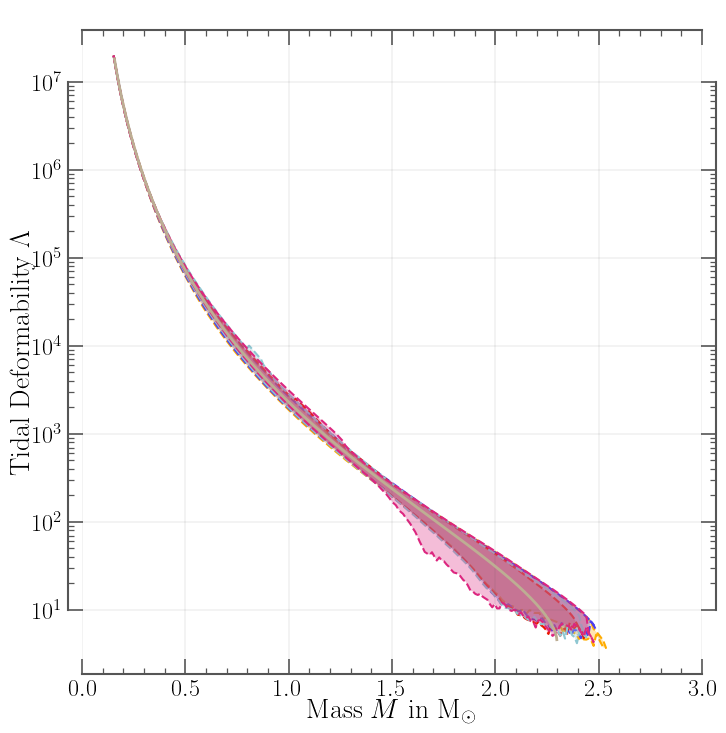

In [10]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52])
ax1.plot(n, injected_eos[2], color='#bdae93', alpha=1, zorder=2, label='Injected EOS')
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_kernels_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
ax1.plot(n, injected_eos[1], color='#bdae93', alpha=1, zorder=2, label='Injected EOS')
pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        labels=["SE_1", "RQ_1", "$\gamma$E_1", "M32_1", "M52_1"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52])

plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_kernels_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52])
ax1.plot(injected_mr[0], injected_mr[1], color='#bdae93', alpha=1, zorder=2, label='Injected EOS')
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_kernels_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52])
ax1.plot(injected_mr[1], injected_mr[2], color='#bdae93', alpha=1, zorder=2, label='Injected EOS')
ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_kernels_mt_posterior.png", dpi=300)
plt.show()

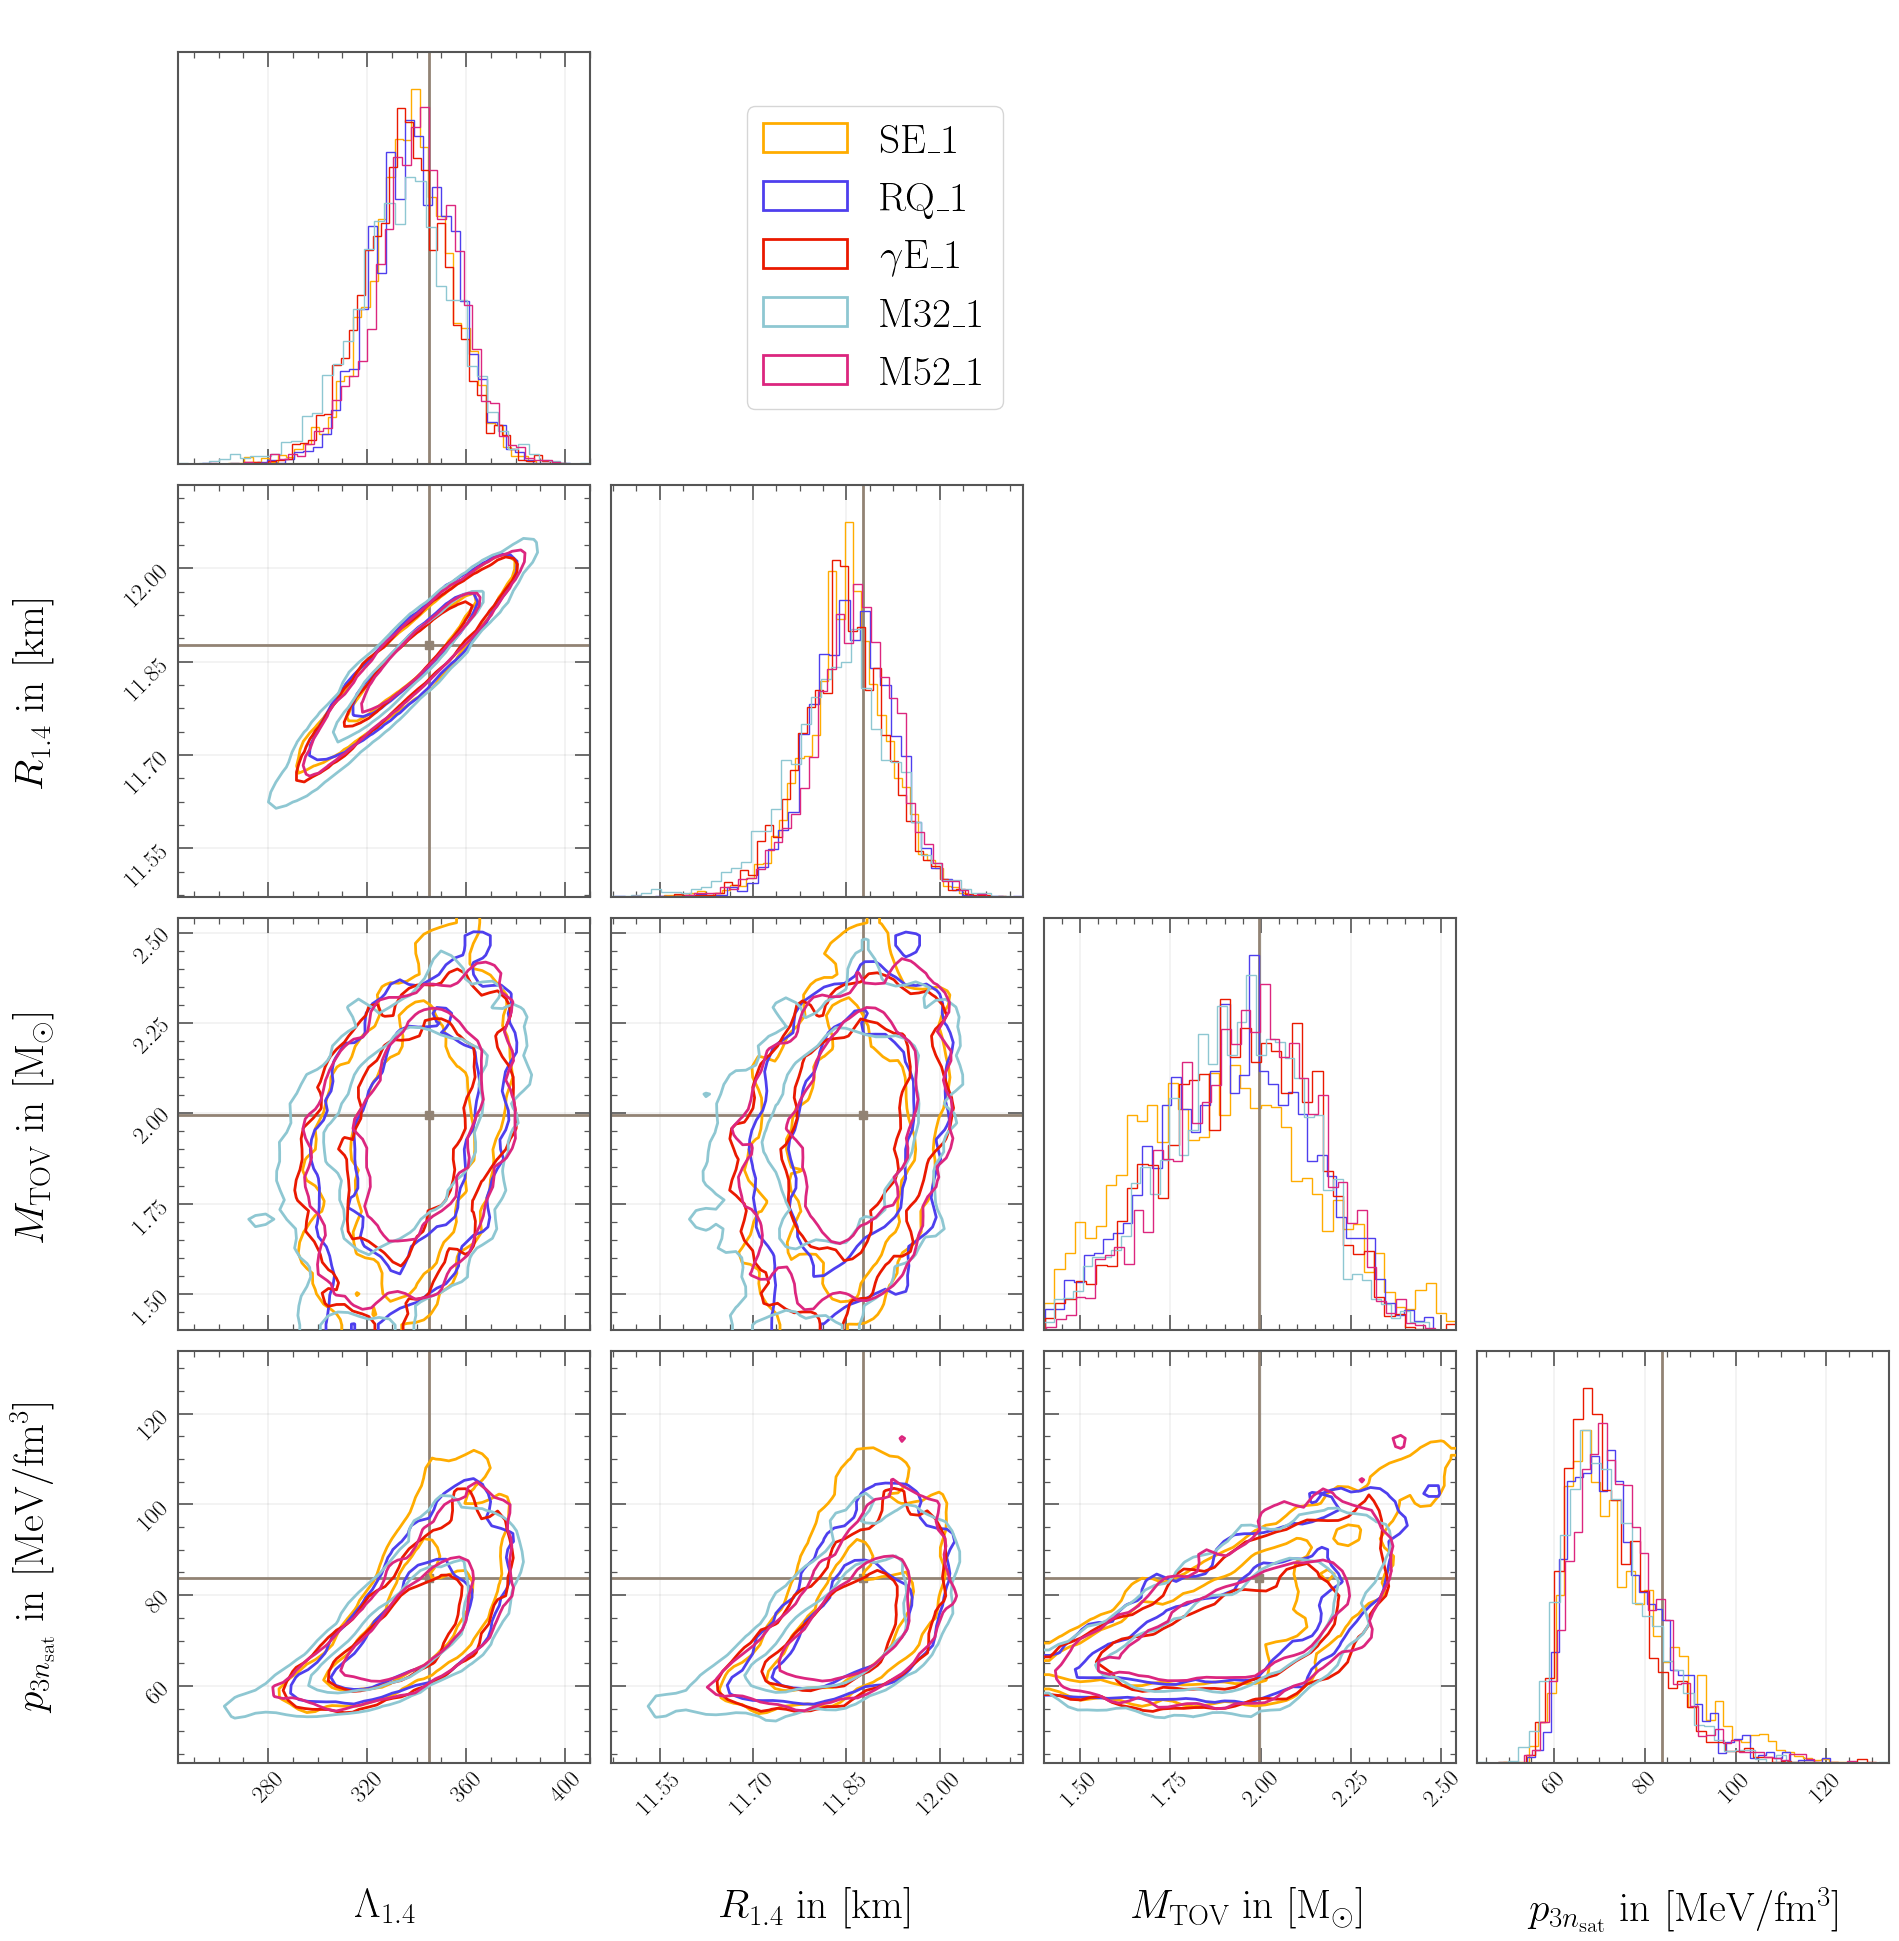

In [8]:
pa.plot_parameters([df_se, df_rq, df_ge, df_m32, df_m52], 
                   injected_params=[injection_param], 
                   title=' ', 
                   labels=["SE_1", "RQ_1", "$\gamma$E_1", "M32_1", "M52_1"],
                   colours = cols,
                   truth_colour = "#928374",
                   contour_fill = False,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   which=2
                   )
plt.savefig(plot_dir + "inj_kernels_posteriors.png", dpi=300)
plt.show()

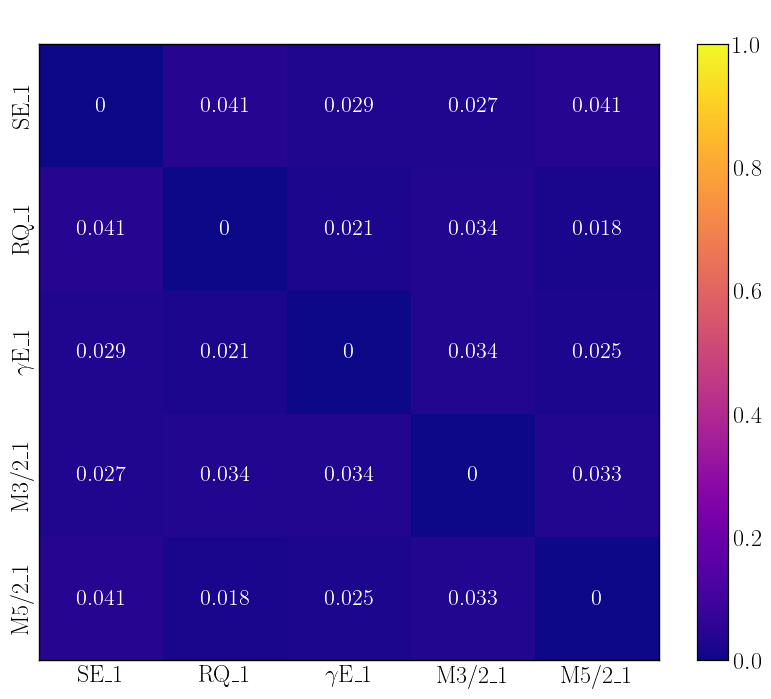

In [9]:
labs=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"]
dfs = [df_se, df_rq, df_ge, df_m32, df_m52]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8))
theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()
plt.savefig(plot_dir + "inj_kernels_JSD.png", dpi=300)
plt.show()

In [10]:
labs=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"]
dfs = [df_se, df_rq, df_ge, df_m32, df_m52]
pa.JSD_average('lambda_14', dfs, bins=40, weighted=True)

Average JSD: 0.030351449374816864


0.030351449374816864

# # Limiting Strategies and Different $\ell$

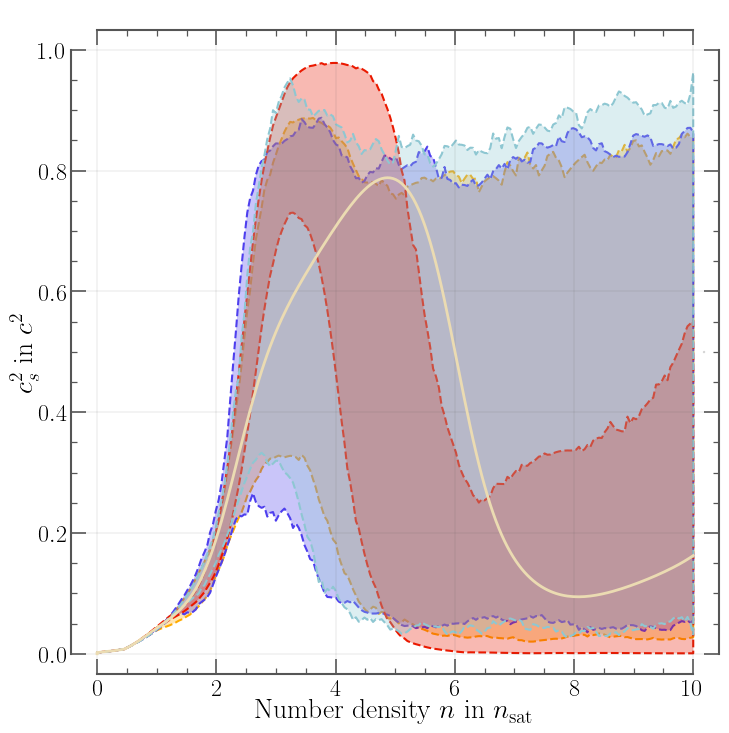

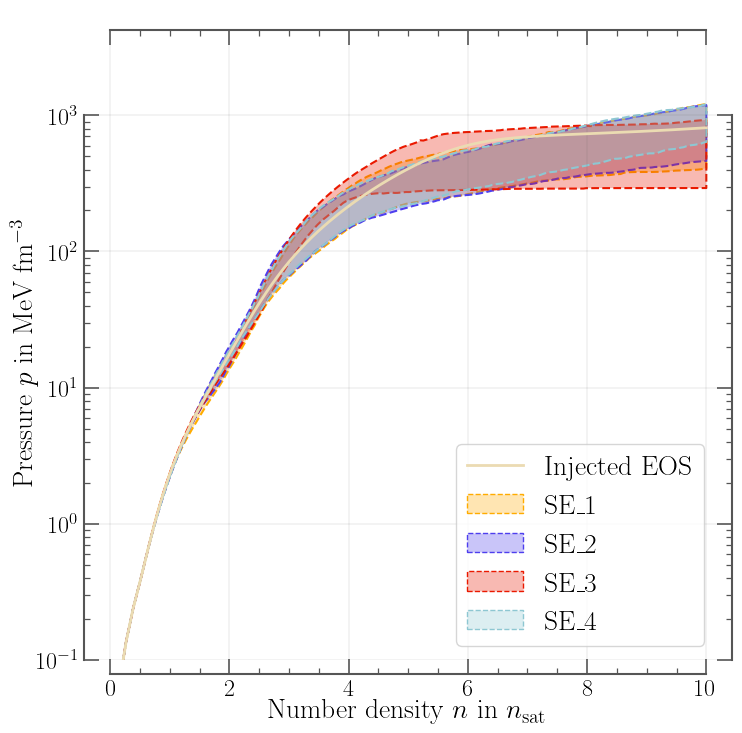

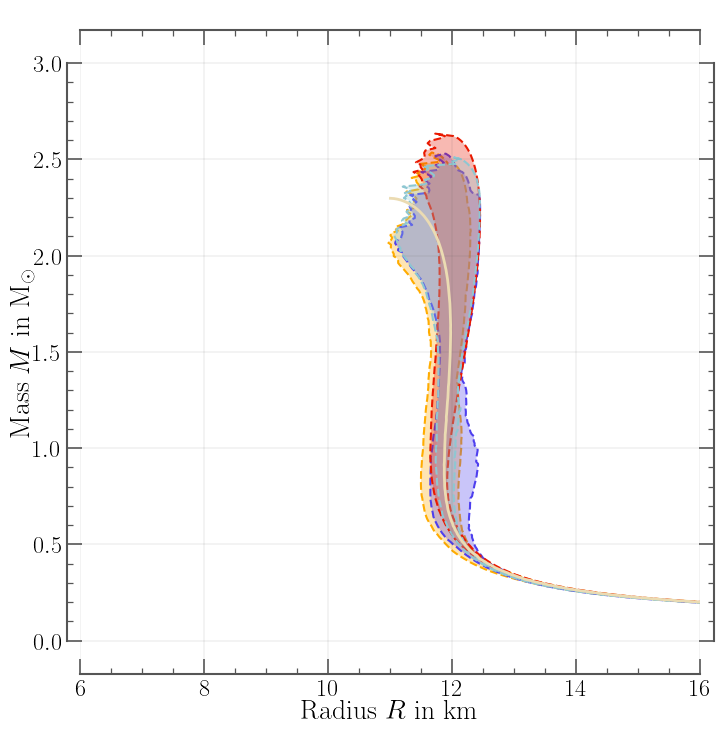

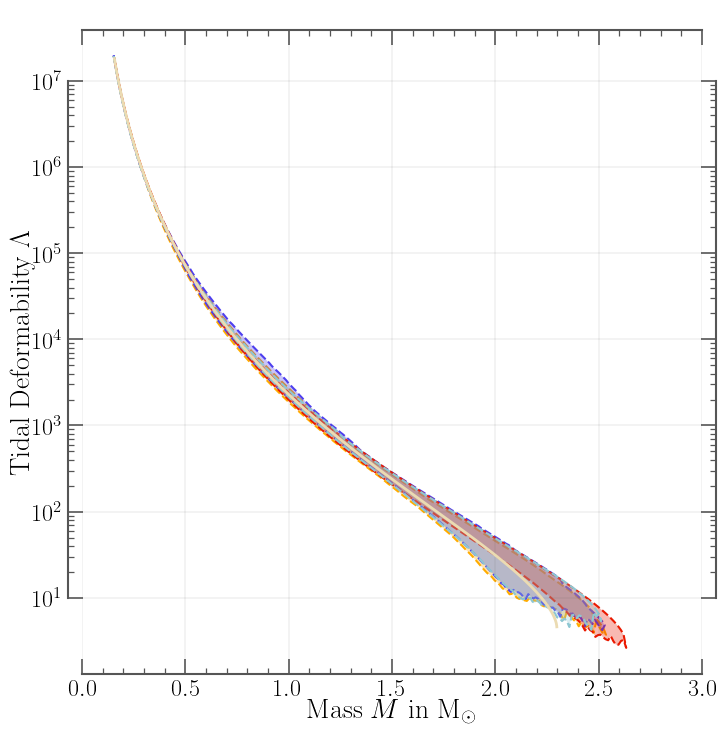

In [12]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post, eos_se2_post, eos_se3_post, eos_se4_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4])
ax1.plot(n, injected_eos[2], color='#ebdbb2', alpha=1, zorder=2, label='Injected EOS')
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_lengthscales_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
ax1.plot(n, injected_eos[1], color='#ebdbb2', alpha=1, zorder=2, label='Injected EOS')
pa.plot_eos_comparisons([eos_se_post, eos_se2_post, eos_se3_post, eos_se4_post], ax1=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post], 
                        labels=["SE_1", "SE_2", "SE_3", "SE_4"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4])

plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_lengthscales_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

pa.plot_eos_comparisons([eos_se_post, eos_se2_post, eos_se3_post, eos_se4_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4])
ax1.plot(injected_mr[0], injected_mr[1], color='#ebdbb2', alpha=1, zorder=2, label='Injected EOS')
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_lengthscales_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se_post, eos_se2_post, eos_se3_post, eos_se4_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4])
ax1.plot(injected_mr[1], injected_mr[2], color='#ebdbb2', alpha=1, zorder=2, label='Injected EOS')
ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_lengthscales_mt_posterior.png", dpi=300)
plt.show()

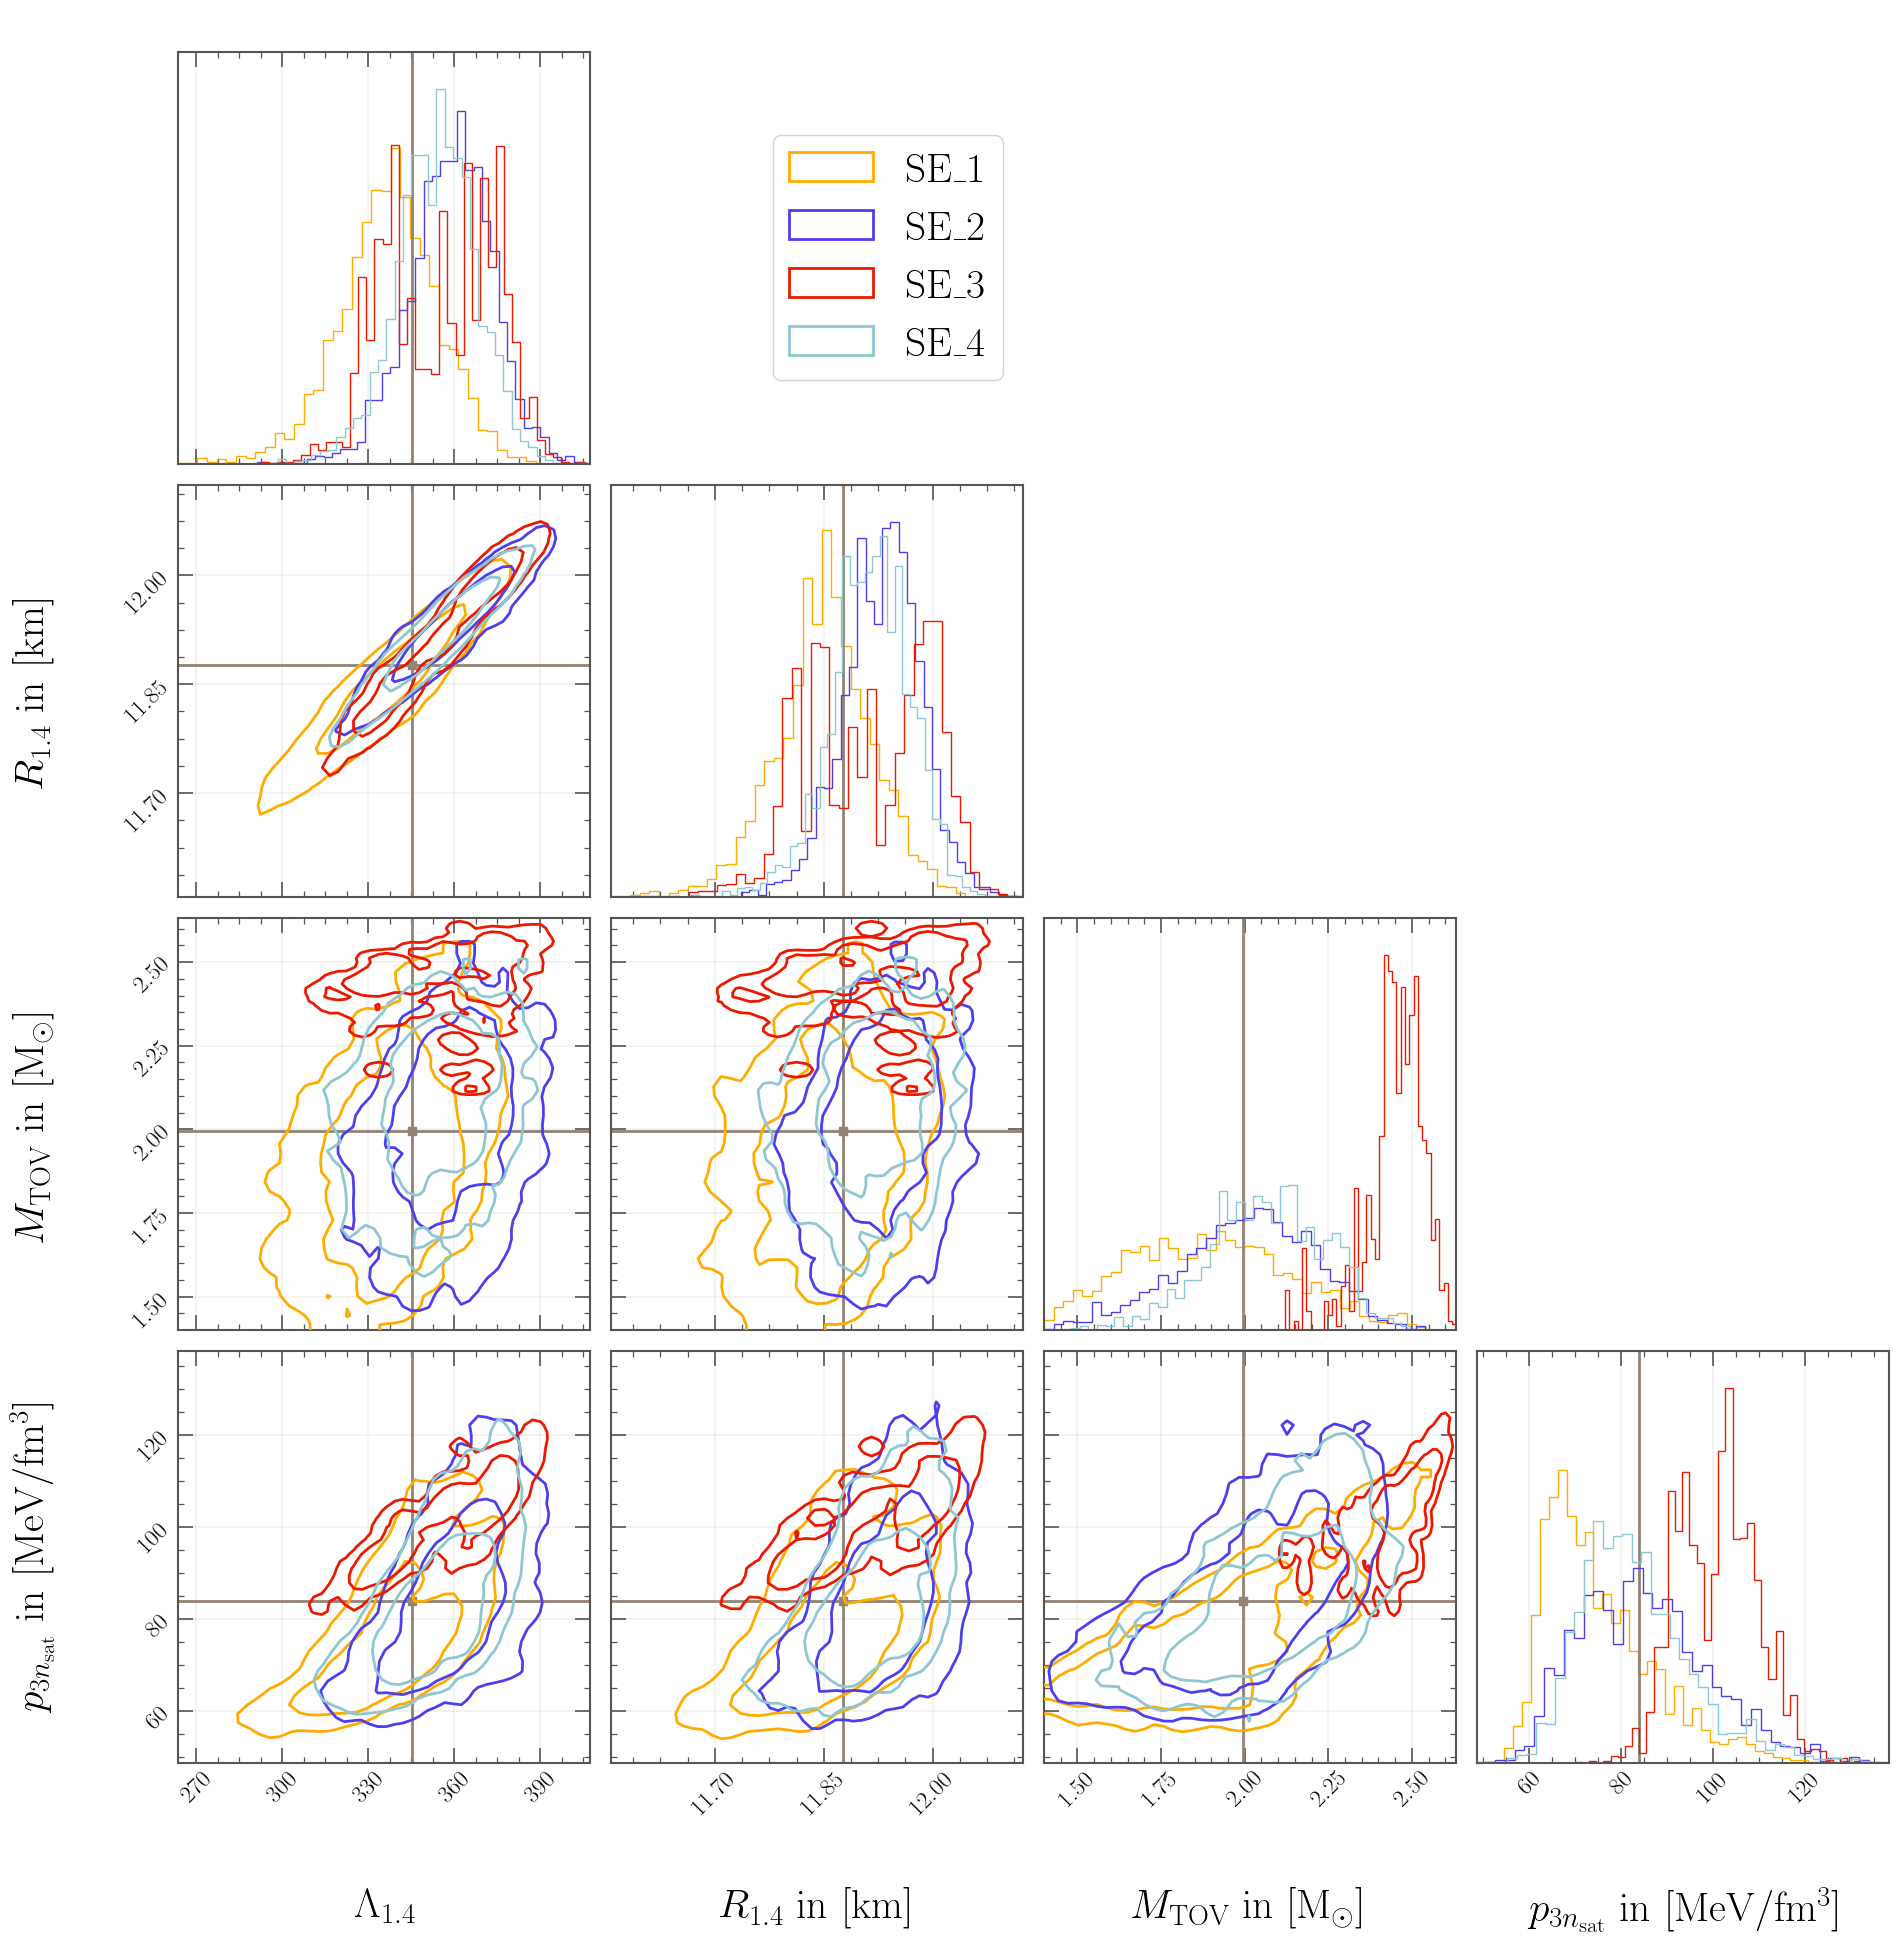

In [11]:
pa.plot_parameters([df_se, df_se2, df_se3, df_se4], 
                   injected_params=[injection_param], 
                   title=' ', 
                   labels=["SE_1", "SE_2", "SE_3", "SE_4"],
                   colours = cols,
                   truth_colour = "#928374",
                   contour_fill = False,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   which=2
                   )
plt.savefig(plot_dir + "inj_lengthscales_posteriors.png", dpi=300)
plt.show()

In [8]:
def posterior_stats(df):
    import corner
    import pandas as pd
    params = ['lambda_14', 'R_14', 'TOV_mass', 'p_3ns']
    stats = {}
    for param in params:
        vals = df.groupby('EOS')[param].first().values
        val_inds = ~np.isnan(vals) & (vals > 0)
        vals = vals[val_inds]
        weights = df.groupby('EOS')['Likelihood'].first().values
        weights = weights[val_inds]

        avg = np.average(vals, weights=weights)
        lower_q = corner.quantile(vals, 0.05, weights=weights)[0]
        upper_q = corner.quantile(vals, 0.95, weights=weights)[0]
        stats[param] = {
            "mean": avg,
            "minus": avg - lower_q,
            "plus": upper_q - avg
        }
    return stats

In [9]:
posterior_stats(df_se3)

{'lambda_14': {'mean': 354.9254270701432,
  'minus': 28.076206022951453,
  'plus': 27.162159998202526},
 'R_14': {'mean': 11.912276271944402,
  'minus': 0.12133159922000303,
  'plus': 0.11706483159830583},
 'TOV_mass': {'mean': 2.4487841316786003,
  'minus': 0.16092530859478016,
  'plus': 0.11618134778842171},
 'p_3ns': {'mean': 100.91570458598376,
  'minus': 12.859268977967801,
  'plus': 13.990609209853261}}

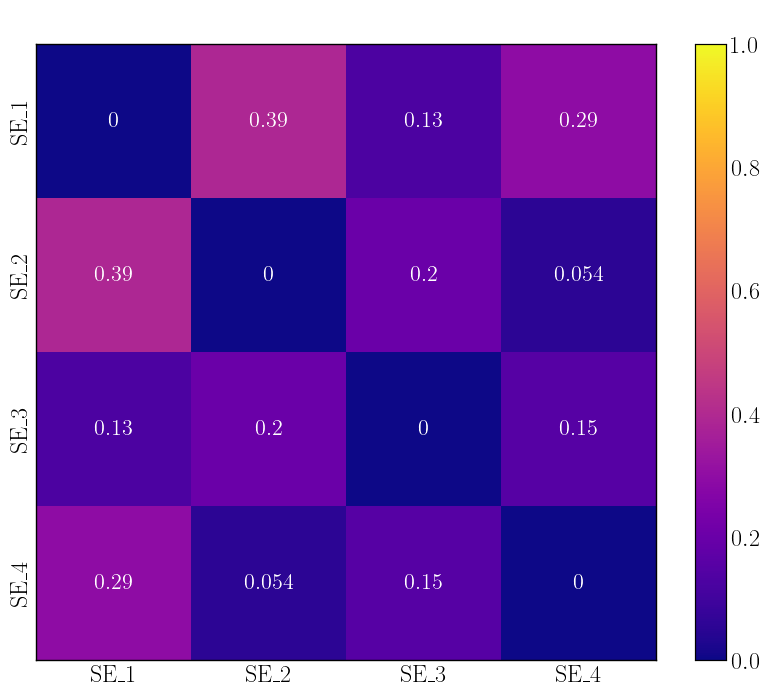

In [14]:
labs=["SE_1", "SE_2", "SE_3", "SE_4"]
dfs = [df_se, df_se2, df_se3, df_se4]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8))
plt.savefig(plot_dir + "inj_lengthscales_JSD.png", dpi=300)
plt.show()

theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

In [34]:
labs=["SE_1", "SE_2", "SE_3", "SE_4"]
dfs = [df_se, df_se2, df_se3, df_se4]
pa.JSD_average('lambda_14', dfs, bins=40, weighted=True)

Average JSD: 0.20242123790019875


0.20242123790019875

show the cs2_4 and cs2_41 are on other sides of the injection so the diff probably is coming from noise realisation. but cs2 and se2 are both narrow constraints but m32 is also narrow and recovers correctly.

In [13]:
df_se41 = pa.load_inj_results(kernel_name = 'SE', set = 41)
#eos_se41, mr_se41 = pa.load_eos_data('SE_10ns_41')

#eos_se41_post, mr_se41_post = pa.get_posterior_eos(df_se41, eos_se41, mr_se41)

In [26]:
eos_rq3, mr_rq3 = pa.load_eos_data('RQ_10ns_3')

inj_lam14 = np.interp(1.4,  mr_rq3[1, injection_param["EOS"], :], mr_rq3[2, injection_param["EOS"], :])

injection_param["lambda_14"] = inj_lam14

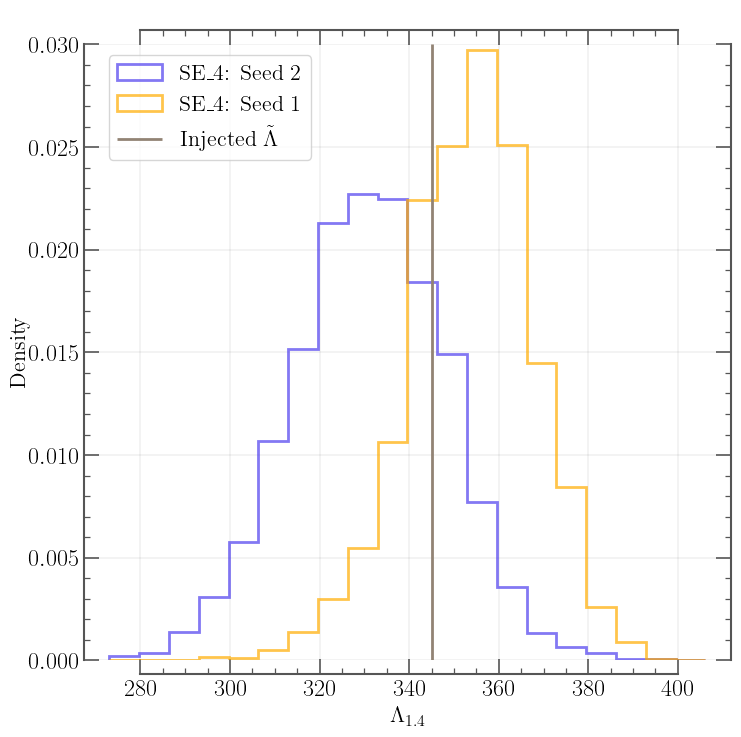

In [15]:
plt.figure(figsize=(8, 8))
plt.hist([df_se4["lambda_14"], df_se41["lambda_14"]], bins=20, 
         density=True, color=['#ffac00', '#4e3fee'], 
         label=["SE_4: Seed 1", "SE_4: Seed 2"],
         alpha=0.7, histtype='step', linewidth=2)
plt.vlines(injection_param["lambda_14"], ymin=0, ymax=0.03, color='#928374', alpha=1, zorder=2, label='Injected $\\tilde{\Lambda}$')
plt.xlabel(r'${\Lambda}_{1.4}$', fontsize=solo_fontsize, labelpad=5)
plt.ylabel('Density', fontsize=solo_fontsize)
plt.title(" ")
plt.legend(fontsize=solo_fontsize)
plt.ylim(0, 0.03)
#plt.xlim(500,700)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "inj_seed.png", dpi=300)
plt.show()

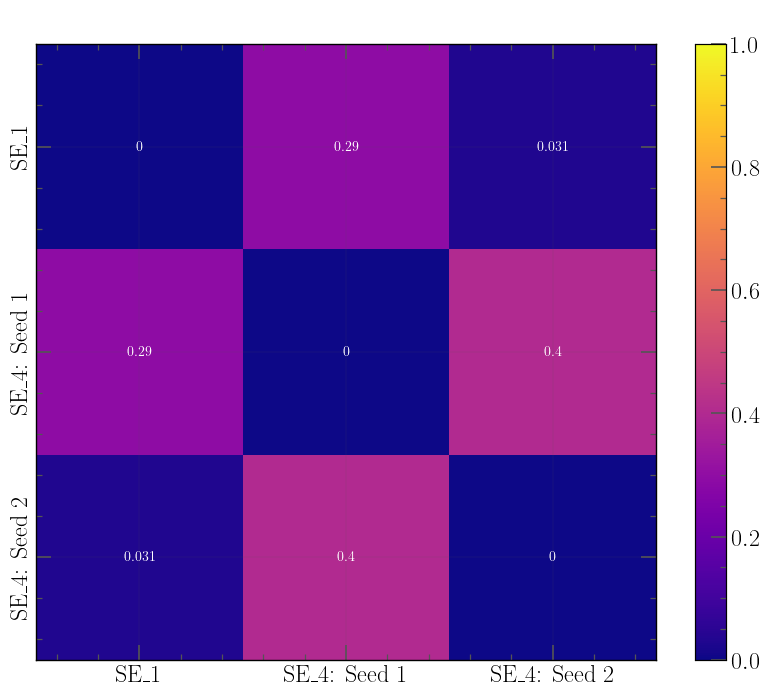

In [32]:
pa.plot_JSD('lambda_14', [df_se, df_se4, df_se41], ["SE_1", "SE_4: Seed 1", "SE_4: Seed 2"], title=" ", bins=40, weighted=True, size=(10, 8))
plt.show()

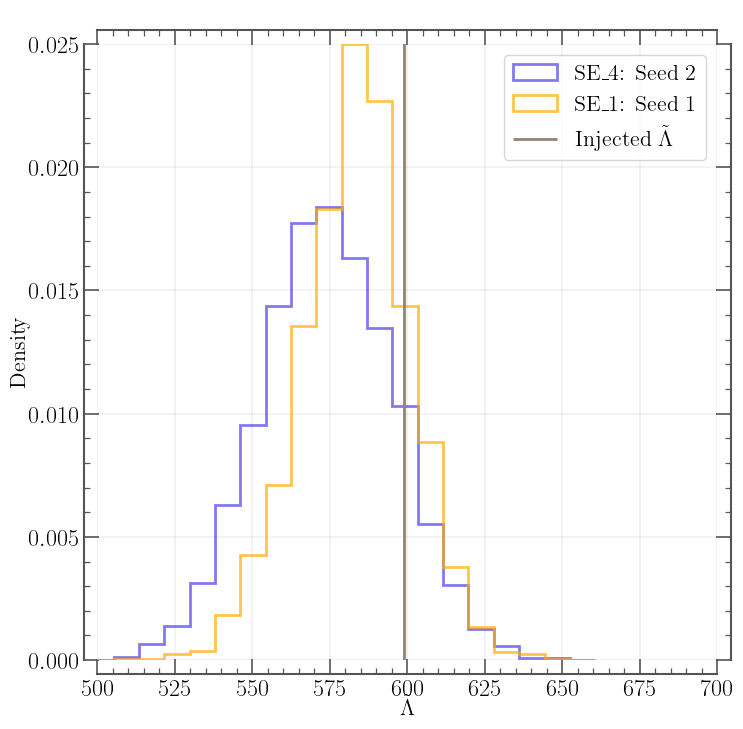

In [42]:
plt.figure(figsize=(8, 8))
plt.hist([df_se["lambda_tilde"], df_se41["lambda_tilde"]], bins=20, 
         density=True, color=['#ffac00', '#4e3fee'], 
         label=["SE_1: Seed 1", "SE_4: Seed 2"],
         alpha=0.7, histtype='step', linewidth=2)
plt.vlines(injection_param["lambda_tilde"], ymin=0, ymax=0.03, color='#928374', alpha=1, zorder=2, label='Injected $\\tilde{\Lambda}$')
plt.xlabel(r'$\tilde{\Lambda}$', fontsize=solo_fontsize)
plt.ylabel('Density', fontsize=solo_fontsize)
plt.title(" ")
plt.legend(fontsize=solo_fontsize)
plt.ylim(0, 0.025)
plt.xlim(500,700)
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "inj_seed.png", dpi=300)
plt.show()